In [1]:
#####################################################################################################################################
#### Prepare input data for moduleviewer
#####################################################################################################################################
import os
import sys
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

os.chdir('/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree/')

#data_folder = '/home/boris/Documents/PhD/gut_brain/IBD/Lloyd-Price2019/data/'
res_folder = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree/Lemon_out/'
expression_location = './Preprocessing/LemonPreprocessed_expression.txt'
expression_complete = './Preprocessing/LemonPreprocessed_complete.txt'
DESeq_groups = './Preprocessing/DESeq_groups.txt'
clusterfile = './Lemon_out/tight_clusters.txt'
topregfile_TF = './Lemon_out/Lovering.topreg.txt'
allregfile_TF = './Lemon_out/Lovering.allreg.txt'
randomregfile_TF = './Lemon_out/Lovering.randomreg.txt'
topregfile_metabolites = './Lemon_out/Metabolites.topreg.txt'
allregfile_metabolites = './Lemon_out/Metabolites.allreg.txt'
randomregfile_metabolites = './Lemon_out/Metabolites.randomreg.txt'

percentile = 2
coherence_threshold = 0.5

In [2]:
#Create mvf file with sample annotations    
with open('./ModuleViewer_files/' + 'sample_mapping.mvf', 'w') as handle:

    # Open DESseq groups as pd dataframe
    annotations = pd.read_csv(DESeq_groups, sep='\t')
    # Add column with sample names if not already present
    if 'Sample_ID' not in annotations.columns:
        annotations['Sample_ID'] = annotations.index
    # Create dictionary sample_mapping with Sample_ID as keys and diagnosis as values
    sample_mapping = dict(zip(annotations['Sample_ID'], annotations['diagnosis']))
    print(len(sample_mapping), 'samples included in the analysis.')

    # Initialize the first lines of the mvf file
    mvf = ['::TYPE=Diagnosis',
           '::GLOBAL',
           '::VALUES=color',
           '::OBJECT=CONDITIONS',
           '::LEGEND=UC:RED|nonIBD:GREEN\tCLinical Status']
    # Add sample annotations to the mvf file
    sample_to_map = ""
    for sample_id in sample_mapping.keys():
        if sample_mapping[sample_id] == 'UC':
            sample_to_map += '|' + sample_id + ':RED'
        elif sample_mapping[sample_id] == 'nonIBD':
            sample_to_map += '|' + sample_id + ':GREEN'
    mvf.append(sample_to_map)
    mvf_str = '\n'.join(mvf)
    print(mvf_str)
    handle.write(mvf_str)

75 samples included in the analysis.
::TYPE=Diagnosis
::GLOBAL
::VALUES=color
::OBJECT=CONDITIONS
::LEGEND=UC:RED|nonIBD:GREEN	CLinical Status
|CSM5FZ1K:RED|CSM5FZ1L:RED|CSM5FZ1N:RED|CSM5FZ1O:RED|CSM5FZ1R:RED|CSM5FZ1S:RED|CSM5FZ1U:RED|CSM5FZ1V:RED|CSM5FZ1W:RED|CSM5FZ2B:RED|CSM5FZ2C:RED|CSM5FZ2H:RED|CSM5FZ2I:RED|CSM5FZ2M:RED|CSM5FZ39:GREEN|CSMDRVXL:RED|CSMDRVXM:RED|CSMDRVXN:RED|CSMDRVXZ:RED|CSMDRVY1:RED|CSMDRVY6:RED|CSMDRVY7:RED|CSMDTZ4X:RED|CSMDTZ4Y:RED|ESM5GEYI:RED|ESM5GEYL:RED|HSM5FZAV:GREEN|HSM5FZAW:GREEN|HSM5FZBB:RED|HSM5FZBD:GREEN|HSM5FZBH:GREEN|HSM6S4FO:GREEN|HSM6S4FP:GREEN|HSM6S4FR:RED|HSM6S4FS:RED|HSM6S4FZ:GREEN|HSM6S4G1:GREEN|HSM6S4G3:GREEN|HSM6S4G4:GREEN|HSM6S4G5:GREEN|HSM6S4G7:GREEN|HSM6S4GH:RED|HSM6S4GI:RED|HSM6S4GN:GREEN|HSM6S4GP:RED|HSM6S4GQ:RED|HSM7H3WX:RED|HSM7H3WY:RED|HSM9JTC3:RED|HSM9JTC7:RED|HSM9JTC8:RED|HSM9UBMQ:RED|HSM9UBMT:GREEN|HSM9UBMU:GREEN|MSM5LWJO:GREEN|MSM5LWJS:GREEN|MSM5LWJU:GREEN|MSM5LWKF:GREEN|MSM5LWL1:RED|MSM5LWL2:RED|MSM719M6:GREEN|MSM719MA:GREEN|MSM719

In [3]:
# how many samples per group?
annotations['diagnosis'].value_counts()

diagnosis
UC        47
nonIBD    28
Name: count, dtype: int64

In [4]:
########################################################################################################################################
# Select regulators FIRST (on original scores), then normalize afterwards
########################################################################################################################################

def selectregulators(allregfile, randomregfile, percentile_cutoff, outfile, ensemble_to_symbol=False):
    """
    Select regulators based on three criteria:
    1. Top percentile_cutoff % of all scores
    2. Score > max random score across all modules
    3. Score >= 10% of max real score within each module
    
    This selection happens on ORIGINAL scores before normalization.
    """
    
    # Create a dictionary with the highest random score per module
    with open(randomregfile, 'r') as handle:
        random_scores = {}
        for line in handle:
            module = line.rstrip().split('\t')[1]
            if module in random_scores:
                if float(line.rstrip().split('\t')[2]) > random_scores[module]:
                    random_scores[module] = float(line.rstrip().split('\t')[2])
            else:
                random_scores[module] = float(line.rstrip().split('\t')[2])
        
    # Print max random score across all modules
    print('Max random score across all modules:')
    max_random_overall = max(random_scores.values())
    print(max_random_overall)

    allreg = pd.read_csv(allregfile, sep = '\t', header = None)
    allreg.columns = ['Regulator', 'Module', 'Score']
    allreg_filtered = allreg[allreg['Score'] >= allreg['Score'].quantile(1 - (percentile_cutoff/100))]
    allreg_filtered = allreg_filtered[allreg_filtered['Score'] > max_random_overall]

    # Get max score per module using groupby
    allreg_filtered['Module'] = allreg_filtered['Module'].astype(str)
    module_max_scores = allreg_filtered.groupby('Module')['Score'].max().to_dict()

    # Filter: only keep regulators with score >= 10% of the max real score for their module
    allreg_filtered['module_max'] = allreg_filtered['Module'].map(module_max_scores)
    allreg_filtered = allreg_filtered[allreg_filtered['Score'] >= 0.1 * allreg_filtered['module_max']]

    module2regulators = {}
    all_scores = []
    
    # Create dict from Module to list of regulators
    for index, row in allreg_filtered.iterrows():
        module = row['Module']
        regulator = row['Regulator']
        score = row['Score']
        
        all_scores.append(score)
        to_append = f"{regulator}|{score}"
        if module in module2regulators:
            module2regulators[module].append(to_append)
        else:
            module2regulators[module] = [to_append]

    
    all_scores.sort(reverse=True)
    print(f"Score range: [{min(all_scores):.4f}, {max(all_scores):.4f}]")
    
    # Convert regulator ensembl id's to gene symbols, store mapping in dictionary
    with open(expression_complete, 'r') as handle5:
         next(handle5)
         global ensemble_mapping
         ensemble_mapping = {}
         for line in handle5:
             line = line.rstrip().split('\t')
             ensembl = line[0]
             symbol = line[1]
             ensemble_mapping[ensembl] = symbol
    
    # Create output regulator file and print some diagnostics
    with open(outfile, 'w') as handle3:
        out = 'Regulator' + '\t' + 'Target' + '\t' + 'Score' + '\t' + 'Overall_rank' + '\n'
        for element in module2regulators:
            regs_for_module = module2regulators[element]
            print(f'{len(regs_for_module)} remain for module {element} with a cutoff of top {percentile_cutoff}% > random and score >= 10% of module max score')
            for reg in regs_for_module:
                regulator = reg.split('|')[0]
                score = reg.split('|')[1]
                rank = str(all_scores.index(float(score)) + 1)
                if ensemble_to_symbol == False:
                    out = out + regulator + '\t' + element + '\t' + str(score) + '\t' + rank +'\n'
                else:
                    out = out + ensemble_mapping[regulator] + '\t' + element + '\t' + str(score) + '\t' + rank + '\n'
        handle3.write(out)

# Run selectregulators on the ORIGINAL (non-normalized) files
print("\n" + "=" * 80)
print("STEP 1: REGULATOR SELECTION (on original LemonTree scores)")
print("=" * 80)

selectregulators(allregfile_TF, randomregfile_TF, percentile, './Lemon_out/Lovering.percentile' + str(percentile) + '.txt', ensemble_to_symbol=False)
selectregulators(allregfile_metabolites, randomregfile_metabolites, percentile, './Lemon_out/Metabolite.percentile' + str(percentile) + '.txt', ensemble_to_symbol=False)

print("\n" + "=" * 80)
print("REGULATOR SELECTION COMPLETE")
print("=" * 80)


STEP 1: REGULATOR SELECTION (on original LemonTree scores)
Max random score across all modules:
3.414206
Score range: [6.4022, 157.7713]
1 remain for module 0 with a cutoff of top 2% > random and score >= 10% of module max score
8 remain for module 1 with a cutoff of top 2% > random and score >= 10% of module max score
5 remain for module 2 with a cutoff of top 2% > random and score >= 10% of module max score
2 remain for module 3 with a cutoff of top 2% > random and score >= 10% of module max score
9 remain for module 4 with a cutoff of top 2% > random and score >= 10% of module max score
5 remain for module 5 with a cutoff of top 2% > random and score >= 10% of module max score
7 remain for module 6 with a cutoff of top 2% > random and score >= 10% of module max score
5 remain for module 7 with a cutoff of top 2% > random and score >= 10% of module max score
7 remain for module 8 with a cutoff of top 2% > random and score >= 10% of module max score
8 remain for module 9 with a cutof

In [5]:
########################################################################################################################################
# STEP 2: Apply sum normalization to SELECTED regulator scores
########################################################################################################################################

def normalize_selected_regulators_sum(selected_file):
    """
    Normalize already-selected regulator scores by dividing by the total sum of scores across all modules, then scale by 100.
    This is applied AFTER selection to make scores comparable across regulator types.
    
    Global sum normalization converts scores to percentages that sum to ~100 across all modules:
    - Each score represents its proportion of the total regulatory activity across all modules
    - Scores across all modules sum to ~100
    - Preserves relative differences between regulators across modules
    - Values are in [0, 100] range
    
    Parameters:
    - selected_file: path to selected regulator file (4 columns: Regulator, Target, Score, Overall_rank)
    
    Returns:
    - normalized_df
    
    The normalized scores OVERWRITE the original file so all downstream steps use normalized scores.
    """
    # Read the selected regulator file
    selected = pd.read_csv(selected_file, sep='\t')
    
    # Store original score range for reporting
    orig_min = selected['Score'].min()
    orig_max = selected['Score'].max()
    orig_sum = selected['Score'].sum()
    
    # Apply GLOBAL sum normalization: divide by total sum across all modules and scale by 100
    total_sum = selected['Score'].sum()
    if total_sum > 0:
        selected['Score'] = selected['Score'] / total_sum * 100.0
    else:
        # Edge case: if total sum is zero, distribute 100 equally across entries
        selected['Score'] = 100.0 / len(selected)
    
    # Save normalized scores back to the SAME file
    selected.to_csv(selected_file, sep='\t', index=False)
    
    print(f"Normalized {len(selected)} selected regulator-module pairs")
    print(f"  Original range: [{orig_min:.4f}, {orig_max:.4f}]")
    print(f"  Original sum (all modules): {orig_sum:.4f}")
    print(f"  Normalized sum (all modules): {selected['Score'].sum():.4f} (scaled to sum=100 across all modules)")
    print(f"  Normalized range: [{selected['Score'].min():.6f}, {selected['Score'].max():.6f}]")
    print(f"  Note: Scores now sum to ~100 across all modules (global normalization and scaling)")
    print(f"  Overwritten: {selected_file}")
    
    return selected

# Apply normalization to selected regulators (overwrites original files)
print("\n" + "=" * 80)
print("STEP 2: NORMALIZING SELECTED REGULATOR SCORES")
print("Global sum normalization divides scores by the TOTAL sum of selected regulator scores, then scales by 100 to make numbers more interpretable")
print("Normalized scores OVERWRITE original files for use in all downstream steps")
print("=" * 80)

print("\n1. Normalizing selected TF regulators...")
tf_normalized = normalize_selected_regulators_sum(
    './Lemon_out/Lovering.percentile' + str(percentile) + '.txt'
)

print("\n2. Normalizing selected Metabolite regulators...")
met_normalized = normalize_selected_regulators_sum(
    './Lemon_out/Metabolite.percentile' + str(percentile) + '.txt'
)


print("\n" + "=" * 80)
print("NORMALIZATION COMPLETE - All downstream steps will use normalized (global-sum scaled) scores")
print("=" * 80)


STEP 2: NORMALIZING SELECTED REGULATOR SCORES
Global sum normalization divides scores by the TOTAL sum of selected regulator scores, then scales by 100 to make numbers more interpretable
Normalized scores OVERWRITE original files for use in all downstream steps

1. Normalizing selected TF regulators...
Normalized 460 selected regulator-module pairs
  Original range: [6.4022, 157.7713]
  Original sum (all modules): 9615.7822
  Normalized sum (all modules): 100.0000 (scaled to sum=100 across all modules)
  Normalized range: [0.066580, 1.640753]
  Note: Scores now sum to ~100 across all modules (global normalization and scaling)
  Overwritten: ./Lemon_out/Lovering.percentile2.txt

2. Normalizing selected Metabolite regulators...
Normalized 547 selected regulator-module pairs
  Original range: [4.3440, 59.9000]
  Original sum (all modules): 5592.5042
  Normalized sum (all modules): 100.0000 (scaled to sum=100 across all modules)
  Normalized range: [0.077675, 1.071077]
  Note: Scores now 

In [6]:
########################################################################################################################################
# Create list files for visualization in moduleviewer
########################################################################################################################################

def createListFile(input_file, output_file):
    # Reading the input file into a Pandas DataFrame
    df = pd.read_csv(input_file, delimiter='\t', header=None)
    print(f"Processing {input_file}: {df.shape[1]} columns")
    
    # Check if df has 2 columns, then it is the cluster file
    if df.shape[1] == 2:
        df.columns = ['gene', 'cluster']
    elif df.shape[1] == 3: # Then it's a topreg file
        df.columns = ['regulator', 'target', 'score']
        df['cluster'] = df['target']
        df['gene'] = df['regulator']
        df = df[['gene', 'cluster']]
    elif df.shape[1] == 4: # Then it's a fold reg file
        df.columns = ['regulator', 'target', 'score', 'overall_rank']
        df['cluster'] = df['target']
        df['gene'] = df['regulator']
        df = df[['gene', 'cluster']]

    # Grouping by cluster and aggregating genes into a '|' separated string
    clusters_and_genes = df.groupby('cluster')['gene'].agg(lambda x: '|'.join(x)).to_dict()
    if 'Target' in clusters_and_genes:
        del clusters_and_genes['Target']
    
    # Formatting the output file
    out = [f"{cluster}\t{genes}\n" for cluster, genes in clusters_and_genes.items()]

    # Writing the output to a new file
    with open(output_file, 'w') as handle:
        handle.write(''.join(out))
    
    print(f"Written {len(clusters_and_genes)} clusters to {output_file}")

# Create list files with all modules (no filtering)
createListFile(clusterfile, './ModuleViewer_files/clusters_list.txt')
createListFile(topregfile_TF, './ModuleViewer_files/TF_regulators.topreg_list_test.txt')
createListFile(topregfile_metabolites, './ModuleViewer_files/Metabolite_regulators.topreg_list.txt')

createListFile('./Lemon_out/Lovering.percentile' + str(percentile) + '.txt', './ModuleViewer_files/Lovering.percentile' + str(percentile) + '_list.txt')
createListFile('./Lemon_out/Metabolite.percentile' + str(percentile) + '.txt', './ModuleViewer_files/Metabolite.percentile' + str(percentile) + '_list.txt')
createListFile(randomregfile_metabolites, './ModuleViewer_files/Metabolite.randomreg_list.txt')

Processing ./Lemon_out/tight_clusters.txt: 2 columns
Written 97 clusters to ./ModuleViewer_files/clusters_list.txt
Processing ./Lemon_out/Lovering.topreg.txt: 3 columns
Written 94 clusters to ./ModuleViewer_files/TF_regulators.topreg_list_test.txt
Processing ./Lemon_out/Metabolites.topreg.txt: 3 columns
Written 93 clusters to ./ModuleViewer_files/Metabolite_regulators.topreg_list.txt
Processing ./Lemon_out/Lovering.percentile2.txt: 4 columns
Written 97 clusters to ./ModuleViewer_files/Lovering.percentile2_list.txt
Processing ./Lemon_out/Metabolite.percentile2.txt: 4 columns
Written 97 clusters to ./ModuleViewer_files/Metabolite.percentile2_list.txt
Processing ./Lemon_out/Metabolites.randomreg.txt: 3 columns
Written 97 clusters to ./ModuleViewer_files/Metabolite.randomreg_list.txt


In [7]:
clusters_list = pd.read_csv('./ModuleViewer_files/clusters_list.txt', sep='\t', header=None)
# Consider the first column as string
clusters_list[0] = clusters_list[0].astype(str)
cluster2gene = dict(zip(clusters_list[0], clusters_list[1]))
print(cluster2gene)

{'0': 'IL27RA|IL21R|CD28|PPP1R18|SASH3|HLA-DOB|CD3D|WDFY4|AGAP2|TIGIT|NCKAP1L|MAP4K1|SCIMP|LBH|NCF1|CD53|CD79A|PHACTR1|CD48|ITGAL|CYTIP|POU2F2|RASAL3|SPOCK2|ICOS|PTPN7|FGD2|TLR6|HLA-DOA|SP140|BTK|SLAMF6|LTA|CORO1A|IKZF1|ACAP1|IL16|AIM2|LCK|TRAF3IP3|PPP1R16B|FMNL3|DOK3|ARHGDIB|CD180|PCED1B|SNX20|WIPF1|P2RY10|CD52|PARVG|PYHIN1|GMFG|RAC2|RASGRP1|JAK3|ANKRD44|PRKCB|SH2D3C|DENND1C|TRAF1|LAT2|APBB1IP|NLRC3|CARD11|LCP1|WAS|RHOH|SUSD3|GRAP|ARHGAP25|TMEM156|FAM78A|PLCG2|P2RY8|PTPRC|SELL|FGD3|ARHGAP15|RUNX3|KLHL6|ADAM19|ZNF831|DOCK2|RFTN1|RASSF2|KMO|SH2D1A|LIMD2|MYO1G|FMNL1|NFATC1|ARHGAP30|ITK|CD5|TNFSF8|HCLS1|PIK3CD|ARHGAP9|CD6', '1': 'ITGA5|ARHGEF15|RGCC|THSD1|LOXL2|PCDH17|IGFBP5|SNCAIP|TNC|RGS5|MEOX1|MGP|SORCS2|COL4A2|ANGPTL2|MCAM|C1R|ADAMTS6|GPR176|CSGALNACT1|MMP19|THY1|APLNR|CDH5|ROBO4|COL6A3|COL7A1|FEZ1|ECSCR|GJC1|FIBIN|CD34|CD93|COL4A1|HTRA3|RBPMS|OSMR|KDR|CTSK|CLEC14A|VWF|ARHGAP23|PDE10A|ANGPT2|BGN|KIFC3|HGF|F2R|GPR68|DYSF|TMEM255B|CTHRC1|TIE1|SERPINI1|NOVA2|ENG|NOTCH4|ADAMTS2|CPXM1|HEG1

In [8]:
########################################################################################################################################
# Calculate module coherence to filter modules before downstream analyses
########################################################################################################################################

# Remove modules with weak co-expression patterns
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

def calculate_module_coherence(expression_file, clusters_dict, coherence_threshold=0.6):
    """
    Calculate eigengenes, kME, and module coherence scores
    
    Parameters:
    - expression_file: path to expression data file
    - clusters_dict: dictionary mapping module -> list of genes
    - coherence_threshold: minimum coherence score to keep module
    
    Returns:
    - modules_to_remove: list of modules with low coherence
    - coherence_scores: dictionary of module -> coherence score
    """
    
    # Load expression data
    expression_data = pd.read_csv(expression_file, sep='\t')
    print(f"Loaded expression data: {expression_data.shape}")
    
    # Set gene symbols as index for easier subsetting
    expression_data_indexed = expression_data.set_index('symbol')
    
    # Remove non-numeric columns (keep only sample columns)
    numeric_cols = expression_data_indexed.select_dtypes(include=[np.number]).columns
    expression_matrix = expression_data_indexed[numeric_cols]
    
    coherence_scores = {}
    eigengenes = {}
    modules_to_remove = []
    
    print("Calculating module coherence scores...")
    
    for module, genes in clusters_dict.items():
        genes = genes.split('|')  # Ensure genes are split correctly
        try:
            # Get expression data for genes in this module
            module_genes_in_data = [gene for gene in genes if gene in expression_matrix.index]
            
            if len(module_genes_in_data) < 3:  # Need at least 3 genes for meaningful analysis
                print(f"Module {module}: Too few genes ({len(module_genes_in_data)}), marking for removal")
                modules_to_remove.append(str(module))
                coherence_scores[module] = 0.0
                continue
            
            # Extract expression data for module genes
            module_expression = expression_matrix.loc[module_genes_in_data]
            
            # Calculate eigengene using PCA (first principal component)
            pca = PCA(n_components=1)
            eigengene = pca.fit_transform(module_expression.T)
            eigengene_series = pd.Series(eigengene.flatten(), index=module_expression.columns)
            eigengenes[module] = eigengene_series
            
            # Calculate kME (correlation of each gene with eigengene)
            kme_values = []
            for gene in module_genes_in_data:
                gene_expression = module_expression.loc[gene]
                correlation, _ = pearsonr(gene_expression, eigengene_series)
                kme_values.append(abs(correlation))  # Use absolute correlation
            
            # Module coherence = mean absolute kME
            coherence_score = np.mean(kme_values)
            coherence_scores[module] = coherence_score
            
            # Check if module should be removed
            if coherence_score < coherence_threshold:
                modules_to_remove.append(str(module))
                print(f"Module {module}: Low coherence ({coherence_score:.3f} < {coherence_threshold}), marking for removal")

        except Exception as e:
            print(f"Error processing module {module}: {str(e)}")
            modules_to_remove.append(str(module))
            coherence_scores[module] = 0.0
    
    return modules_to_remove, coherence_scores, eigengenes

# Calculate module coherence using the cluster2gene dictionary
print("Analyzing module coherence...")
low_coherence_modules, coherence_scores, module_eigengenes = calculate_module_coherence(
    expression_complete, 
    cluster2gene, 
    coherence_threshold=coherence_threshold
)

# Display results
print(f"\nCoherence Analysis Results:")
print(f"Total modules analyzed: {len(coherence_scores)}")
print(f"Modules with low coherence: {len(low_coherence_modules)}")
print(f"Low coherence modules: {low_coherence_modules}")

# Filter cluster2gene dictionary to remove low coherence modules
print(f"Original number of modules: {len(cluster2gene)}")
filtered_cluster2gene = {k: v for k, v in cluster2gene.items() if str(k) not in low_coherence_modules}
cluster2gene = filtered_cluster2gene
print(f"Modules after coherence filtering: {len(cluster2gene)}")

# How many modules do we keep?
n_modules = len(cluster2gene)
print(f"n_modules set to: {n_modules}")

# Create a DataFrame with coherence scores for analysis
coherence_df = pd.DataFrame(list(coherence_scores.items()), columns=['Module', 'Coherence_Score'])
coherence_df = coherence_df.sort_values('Coherence_Score', ascending=False)

# Save coherence scores to file for future reference
coherence_df.to_csv('Module_coherence_scores.txt', sep='\t', index=False)
print("Coherence scores saved to Module_coherence_scores.txt")

Analyzing module coherence...
Loaded expression data: (5762, 77)
Calculating module coherence scores...
Module 55: Low coherence (0.465 < 0.5), marking for removal
Module 58: Low coherence (0.480 < 0.5), marking for removal
Module 65: Low coherence (0.471 < 0.5), marking for removal
Module 76: Low coherence (0.467 < 0.5), marking for removal
Module 80: Low coherence (0.433 < 0.5), marking for removal
Module 87: Low coherence (0.348 < 0.5), marking for removal
Module 88: Low coherence (0.490 < 0.5), marking for removal
Module 89: Low coherence (0.448 < 0.5), marking for removal
Module 90: Low coherence (0.396 < 0.5), marking for removal
Module 92: Low coherence (0.487 < 0.5), marking for removal
Module 96: Low coherence (0.473 < 0.5), marking for removal

Coherence Analysis Results:
Total modules analyzed: 97
Modules with low coherence: 11
Low coherence modules: ['55', '58', '65', '76', '80', '87', '88', '89', '90', '92', '96']
Original number of modules: 97
Modules after coherence filt

In [9]:
########################################################################################################################################
# Prioritize modules by coherence scores (higher coherence = better quality)
########################################################################################################################################

def Prioritize_modules_coherence(coherence_scores, filtered_modules):
    """
    Prioritize modules based on coherence scores (higher is better)
    Only processes modules that passed coherence filtering
    """
    
    # Filter coherence scores to only include modules that passed filtering
    filtered_coherence = {k: v for k, v in coherence_scores.items() if str(k) in filtered_modules}
    
    # Sort by coherence score (descending - higher coherence is better)
    modules_ordered = {k: v for k, v in sorted(filtered_coherence.items(), key=lambda item: item[1], reverse=True)}
    
    # Convert to df and sort
    df = pd.DataFrame(list(modules_ordered.items()), columns=['Module', 'coherence_score'])
    print(df)
    df.to_csv('Module_prioritization_coherence.txt', sep='\t', index=False)
    return modules_ordered

# Get list of filtered module names
filtered_module_names = list(cluster2gene.keys())

print("Prioritizing modules by coherence scores...")
order = Prioritize_modules_coherence(coherence_scores, filtered_module_names)
print(f"Modules ordered by coherence scores (filtered): {len(order)}")

# Update n_modules to reflect filtered modules
n_modules = len(order)
print(f"Final n_modules after filtering and prioritization: {n_modules}")

Prioritizing modules by coherence scores...
   Module  coherence_score
0       0         0.945105
1      69         0.935106
2      10         0.934546
3       3         0.923335
4       1         0.906744
..    ...              ...
81     77         0.545113
82     56         0.542543
83     71         0.538200
84     72         0.534655
85     53         0.534151

[86 rows x 2 columns]
Modules ordered by coherence scores (filtered): 86
Final n_modules after filtering and prioritization: 86


In [10]:
# Module prioritization completed - using coherence-based ordering
print("Using coherence-based prioritization for filtered modules")
to_remove = low_coherence_modules

Using coherence-based prioritization for filtered modules


In [11]:
# Use all filtered modules regardless of prioritization method
# No modules are removed based on expression significance - they are only ordered
print(f"to_remove list: {to_remove}")

# Use all modules that passed coherence filtering
specific_modules = list(order.keys())

# Convert to strings to ensure consistency
specific_modules = [str(module) for module in specific_modules]
print(f'{len(specific_modules)} modules in specific_modules')

# write txt file with modules to keep
if not os.path.exists('./Networks'):
    os.makedirs('./Networks')
with open('./Networks/specific_modules.txt', 'w') as handle:
    for module in specific_modules:
        handle.write(module + '\n')
        
print(f"Specific modules saved to ./Networks/specific_modules.txt")

to_remove list: ['55', '58', '65', '76', '80', '87', '88', '89', '90', '92', '96']
86 modules in specific_modules
Specific modules saved to ./Networks/specific_modules.txt


In [12]:
########################################################################################################################################
# Summary of filtering and prioritization results
########################################################################################################################################

print("="*80)
print("SUMMARY OF MODULE FILTERING AND PRIORITIZATION")
print("="*80)

print(f"Original number of modules: {len(coherence_scores)}")
print(f"Modules removed due to low coherence (< {coherence_threshold}): {len(low_coherence_modules)}")
print(f"Modules remaining after coherence filtering: {len(cluster2gene)}")

print(f"\nPrioritization method: Module coherence scores")
print(f"All coherence-filtered modules used for network construction: {len(specific_modules)}")

print(f"\nFinal network will be built using {len(specific_modules)} modules")
print(f"Coherence threshold used: {coherence_threshold}")
print(f"Fold cutoff for regulators: {percentile}")
print("\nIMPORTANT: No modules are removed based on expression significance.")
print("Modules are only filtered by coherence, then ordered by expression p-values or coherence scores.")

print("="*80)

SUMMARY OF MODULE FILTERING AND PRIORITIZATION
Original number of modules: 97
Modules removed due to low coherence (< 0.5): 11
Modules remaining after coherence filtering: 86

Prioritization method: Module coherence scores
All coherence-filtered modules used for network construction: 86

Final network will be built using 86 modules
Coherence threshold used: 0.5
Fold cutoff for regulators: 2

IMPORTANT: No modules are removed based on expression significance.
Modules are only filtered by coherence, then ordered by expression p-values or coherence scores.


In [13]:
########################################################################################################################################
# Build the network with selected regulators and modules
########################################################################################################################################

def build_network(reg_files, specific_modules_list=None):
    # Initialize an empty list to store DataFrames
    dfs = []

    global modules_name
    global modules_to_keep

    if specific_modules_list is not None:
        modules_to_keep = specific_modules_list
        modules_name = f'selected_{len(modules_to_keep)}'
        print(f'Building network for {len(modules_to_keep)} selected modules')
    else:
        # Default: use all filtered modules
        modules_to_keep = list(cluster2gene.keys())
        modules_to_keep = [str(module) for module in modules_to_keep]
        modules_name = f'all_{len(modules_to_keep)}'
        print(f'Building network for all {len(modules_to_keep)} filtered modules')

    print(f'Modules to keep: {modules_to_keep[:10]}...')  # Show first 10

    for reg_file in reg_files: # Loop over regulator files
        data = pd.read_csv(reg_file, sep='\t')
        if len(data.columns) == 3:
            data.columns = ['Regulator', 'Target', 'Score']
        elif len(data.columns) == 4:
            data.columns = ['Regulator', 'Target', 'Score', 'Overall_rank']

        data['Target'] = data['Target'].astype(str)
        
        # Loop over this dataframe
        for index, row in data.iterrows():
            # Get Regulator
            regulator = row['Regulator']
            # Get module
            module = row['Target']
            
            if str(module) in modules_to_keep:
                genes = cluster2gene.get(module, [])
                if isinstance(genes, str):
                    genes = genes.split('|')  # Ensure genes are split correctly
                
                for gene in genes:
                    if 'Lovering' in reg_file:
                        # Create a DataFrame for each gene
                        gene_df = pd.DataFrame({'Regulator': [regulator], 'Target': [gene], 'Score': [row['Score']], 'Lemon_module': str(module), 'Type': ['TF-gene']})
                    elif 'Metabolite' in reg_file:
                        gene_df = pd.DataFrame({'Regulator': [regulator], 'Target': [gene], 'Score': [row['Score']], 'Lemon_module': str(module), 'Type': ['Metabolite-gene']})
                    
                    dfs.append(gene_df)  # Append the DataFrame to the list
    
    # Concatenate all DataFrames in the list
    if dfs:
        network_df = pd.concat(dfs, ignore_index=True)
    else:
        print("Warning: No network edges found!")
        network_df = pd.DataFrame(columns=['Regulator', 'Target', 'Score', 'Lemon_module', 'Type'])

    # Create folder Networks if it does not exist
    if not os.path.exists('./Networks'):
        os.makedirs('./Networks')

    # Write to file
    network_df.to_csv(f'./Networks/LemonNetwork_percentile{percentile}_{modules_name}modules.txt', sep='\t', index=False)
    print(f"Network saved to: ./Networks/LemonNetwork_percentile{percentile}_{modules_name}modules.txt")

    return network_df

# Build network with specific modules
reg_files = [f'./Lemon_out/Lovering.percentile{percentile}.txt', f'./Lemon_out/Metabolite.percentile{percentile}.txt']
network_df = build_network(reg_files, specific_modules_list=specific_modules)

Building network for 86 selected modules
Modules to keep: ['0', '69', '10', '3', '1', '6', '83', '93', '8', '74']...
Network saved to: ./Networks/LemonNetwork_percentile2_selected_86modules.txt


In [14]:
network_df

,Regulator,Target,Score,Lemon_module,Type
0,SP140,IL27RA,1.640753,0,TF-gene
1,SP140,IL21R,1.640753,0,TF-gene
2,SP140,CD28,1.640753,0,TF-gene
3,SP140,PPP1R18,1.640753,0,TF-gene
4,SP140,SASH3,1.640753,0,TF-gene
...,...,...,...,...,...
41357,C36_4_PC_plasmalogen,HOXA11,0.127858,95,Metabolite-gene
41358,C36_4_PC_plasmalogen,C8orf48,0.127858,95,Metabolite-gene
41359,C36_4_PC_plasmalogen,SLC22A3,0.127858,95,Metabolite-gene
41360,C36_4_PC_plasmalogen,ADAMTS14,0.127858,95,Metabolite-gene


In [15]:
# How many unique genes in Target column?
print(f'The network contains {network_df["Target"].nunique()} unique genes.')
for reg_type in network_df['Type'].unique():

    print(f'The network contains {network_df[network_df["Type"] == reg_type]["Regulator"].nunique()} unique {reg_type.split("-")[0]} regulators.')

The network contains 3543 unique genes.
The network contains 237 unique TF regulators.
The network contains 199 unique Metabolite regulators.


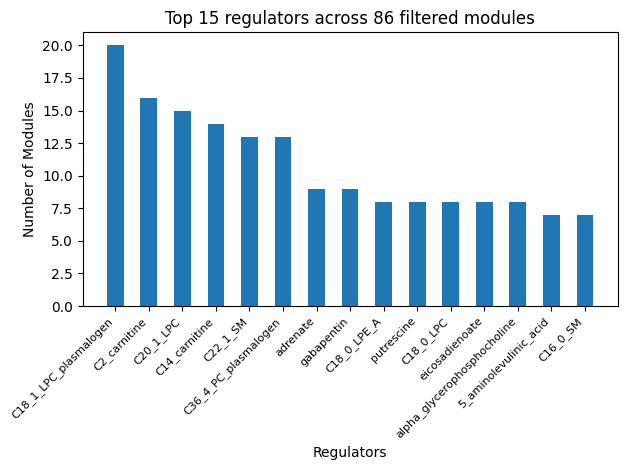

Saved plot for 199 unique regulators


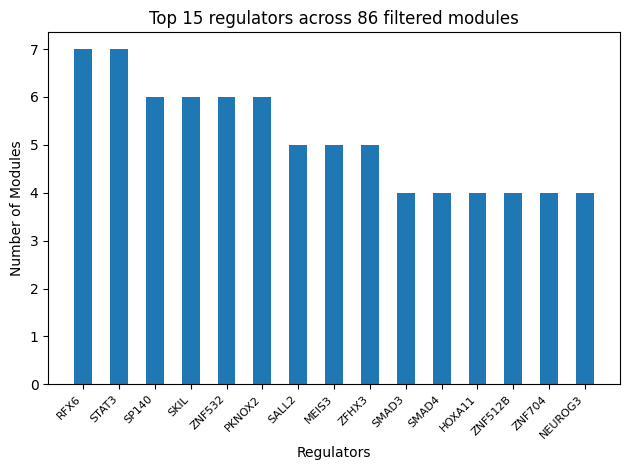

Saved plot for 237 unique regulators


In [16]:
# Create similar plot but only for the top 30 connected regulators (filtered modules only)
def create_reg_distribution_top_filtered(reg_file_list, modules_to_keep):

    with open('./ModuleViewer_files/' + reg_file_list, 'r') as handle:
        regs = {}
        for line in handle:
            line = line.rstrip().split('\t')
            if len(line) < 2:
                continue
            module = line[0]
            if str(module) not in [str(m) for m in modules_to_keep]:
                continue
            regulators = line[1].split('|')
            for regulator in regulators:
                if regulator in regs:
                    regs[regulator] += 1
                else:
                    regs[regulator] = 1

    if not regs:
        print(f"Warning: No regulators found for file {reg_file_list}")
        return
    
    # Sort keys based on counts in decreasing order
    sorted_keys = sorted(regs, key=regs.get, reverse=True)

    # Extract sorted keys and counts
    sorted_counts = [regs[key] for key in sorted_keys]

    # Plotting
    fig, ax = plt.subplots()
    bars = ax.bar(sorted_keys[:15], sorted_counts[:15], width=0.5)

    ax.set_xlabel('Regulators')
    ax.set_ylabel('Number of Modules')
    ax.set_title(f'Top 15 regulators across {len(modules_to_keep)} filtered modules')

    ax.set_xticks(range(len(sorted_keys[:15])))
    ax.set_xticklabels(sorted_keys[:15], rotation=45, ha='right', fontsize=8)  # Adjust fontsize for better readability
    plt.tight_layout()  # Ensure labels are not cut off

    # Explicitly set the face color
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Save the plot with a white background
    plt.savefig(reg_file_list[:-3] + f'distribution_plot_top15_filtered_{len(modules_to_keep)}modules.png', 
                facecolor=fig.get_facecolor(), edgecolor='none', dpi=300)

    plt.show()
    print(f"Saved plot for {len(sorted_keys)} unique regulators")

# Create plots for filtered modules
if 'modules_to_keep' in globals():
    create_reg_distribution_top_filtered(f'Metabolite.percentile{percentile}_list.txt', modules_to_keep)
    create_reg_distribution_top_filtered(f'Lovering.percentile{percentile}_list.txt', modules_to_keep)
else:
    print("Warning: modules_to_keep not defined, using all available modules")
    create_reg_distribution_top_filtered(f'Metabolite.percentile{percentile}_list.txt', list(cluster2gene.keys()))
    create_reg_distribution_top_filtered(f'Lovering.percentile{percentile}_list.txt', list(cluster2gene.keys()))

In [17]:
########################################################################################################################################
# Create dictionary that maps regulators to targets for selected modules
########################################################################################################################################

metabolites_network = network_df[network_df['Type'] == 'Metabolite-gene']
TFs_network = network_df[network_df['Type'] == 'TF-gene']

metabolites2targets = {}
for index, row in metabolites_network.iterrows():
    metabolite = row['Regulator']
    target = row['Target']
    if metabolite in metabolites2targets:
        metabolites2targets[metabolite].append(target)
    else:
        metabolites2targets[metabolite] = [target]

TFs2targets = {}
for index, row in TFs_network.iterrows():
    TF = row['Regulator']
    target = row['Target']
    if TF in TFs2targets:
        TFs2targets[TF].append(target)
    else:
        TFs2targets[TF] = [target]

regulator2module = {}
for index, row in network_df.iterrows():
    regulator = row['Regulator']
    module = row['Lemon_module']
    if regulator in regulator2module:
        if module not in regulator2module[regulator]:
            regulator2module[regulator].append(module)
    else:
        regulator2module[regulator] = [module]

#print(regulator2module)

In [18]:
# Create df with metabolites and their targets
metabolites2targets_df = pd.DataFrame(list(metabolites2targets.items()), columns=['Regulator', 'Targets'])
TFs2targets_df = pd.DataFrame(list(TFs2targets.items()), columns=['Regulator', 'Targets'])
# Convert list of targets to | separated string
metabolites2targets_df['Targets'] = metabolites2targets_df['Targets'].apply(lambda x: '|'.join(x))
TFs2targets_df['Targets'] = TFs2targets_df['Targets'].apply(lambda x: '|'.join(x))

# Use actual number of modules for filename
actual_n_modules = len(specific_modules)

# Write to file
metabolites2targets_df.to_csv(f'./Networks/Metabolites2targets_percentile{percentile}_{actual_n_modules}_modules.txt', sep='\t', index=False)
TFs2targets_df.to_csv(f'./Networks/TFs2targets_percentile{percentile}_{actual_n_modules}_modules.txt', sep='\t', index=False)

print(f"Saved target files for {actual_n_modules} filtered modules")
print(f"Metabolites: {len(metabolites2targets_df)} regulators")
print(f"TFs: {len(TFs2targets_df)} regulators")

Saved target files for 86 filtered modules
Metabolites: 199 regulators
TFs: 237 regulators


In [19]:
########################################################################################################################################
# Create ranked regulator file that summarizes regulator scores across modules that are retained in the network after selection 
########################################################################################################################################

def create_ranked_reg_file(network, n_modules_actual):
    # network = pd.read_csv(networkfile, sep='\t')
    type = network['Type'].unique()[0].split('-')[0]
    # remove Target and Type columns
    network = network.drop(['Target', 'Type'], axis=1)
    
    # Group by Regulator and calculate the mean score (actually mean = score since all regulator-module scores are the same within a single module)
    # Group by 'Regulator' and retain only 'Lemon_module' and 'Score' columns
    grouped_df = network.groupby(['Regulator', 'Lemon_module'])[['Score']].first().reset_index()
    
    # Group by 'Regulator' and sum the 'Score' column
    sum_scores_df = grouped_df.groupby('Regulator')[['Score']].sum().reset_index()

    # Sort the dataframe based on the sum of scores
    sum_scores_df = sum_scores_df.sort_values(by='Score', ascending=False)

    # Add columns with number of target modules, number of target genes, target modules and target genes
    for row in sum_scores_df.iterrows():
        regulator = row[1]['Regulator']
        modules = regulator2module[regulator]
        sum_scores_df.at[row[0], 'N_modules'] = int(len(modules))
        sum_scores_df.at[row[0], 'N_targets'] = int(len(metabolites2targets[regulator])) if regulator in metabolites2targets else int(len(TFs2targets[regulator]))
       
        sum_scores_df.at[row[0], 'Modules'] = '|'.join(modules)
        if regulator in metabolites2targets:
            sum_scores_df.at[row[0], 'Targets'] = '|'.join(metabolites2targets[regulator])
        else:
            sum_scores_df.at[row[0], 'Targets'] = '|'.join(TFs2targets[regulator])
    
    print(f"Top {type} regulators:")
    print(sum_scores_df.head())
    
    # Write to file
    sum_scores_df.to_csv(f'./Networks/Network_percentile{percentile}_{n_modules_actual}_modules_{type}_ranked_regulators.txt', sep='\t', index=False)
    print(f"Saved to: ./Networks/Network_percentile{percentile}_{n_modules_actual}_modules_{type}_ranked_regulators.txt")

# Use the actual number of modules in the network
actual_n_modules = len(specific_modules)
create_ranked_reg_file(metabolites_network, actual_n_modules)
create_ranked_reg_file(TFs_network, actual_n_modules)

Top Metabolite regulators:
                Regulator     Score  N_modules  N_targets  \
38  C18_1_LPC_plasmalogen  4.714106       20.0     1204.0   
58           C2_carnitine  4.028521       16.0      766.0   
51               C22_1_SM  3.910437       13.0      911.0   
46              C20_1_LPC  3.577309       15.0      860.0   
21          C14_carnitine  3.574037       14.0      844.0   

                                              Modules  \
38  2|7|8|9|14|16|20|22|23|25|46|49|52|56|64|71|75...   
58       2|7|9|16|23|26|27|34|47|62|68|70|71|74|75|84   
51                  0|2|3|5|8|10|15|19|20|42|50|62|93   
46           0|3|8|9|12|17|18|20|25|34|39|47|56|81|84   
21              0|1|4|5|11|15|23|34|42|53|61|83|86|93   

                                              Targets  
38  CLCN2|SLC26A3|B3GNT8|EDN3|GUCA2B|CHP2|GUCA2A|M...  
58  CLCN2|SLC26A3|B3GNT8|EDN3|GUCA2B|CHP2|GUCA2A|M...  
51  IL27RA|IL21R|CD28|PPP1R18|SASH3|HLA-DOB|CD3D|W...  
46  IL27RA|IL21R|CD28|PPP1R18|SASH3|HLA

In [20]:
########################################################################################################################################
# Create regulator overview tables: number of modules, summed score, highest score - ordered by descending n_modules
########################################################################################################################################

def create_regulator_overview_table(network, n_modules_actual):
    """
    Create an overview table for regulators with:
    - Number of modules they regulate
    - Summed score across all modules
    - Highest regulator-module score
    Ordered by descending summed score.
    """
    type_name = network['Type'].unique()[0].split('-')[0]
    
    # Remove Target and Type columns for processing
    network_proc = network.drop(['Target', 'Type'], axis=1)
    
    # Group by Regulator and Lemon_module to get unique regulator-module pairs with their scores
    grouped_df = network_proc.groupby(['Regulator', 'Lemon_module'])[['Score']].first().reset_index()
    
    # For each regulator, calculate:
    # 1. Number of modules
    # 2. Sum of scores across modules
    # 3. Highest score across modules
    regulator_stats = grouped_df.groupby('Regulator').agg({
        'Lemon_module': 'count',  # Number of modules
        'Score': ['sum', 'max']   # Sum and max of scores
    }).reset_index()
    
    # Flatten column names
    regulator_stats.columns = ['Regulator', 'N_modules', 'Summed_score', 'Highest_score']
    
    # Sort by summed score (descending)
    regulator_stats = regulator_stats.sort_values(by='Summed_score', ascending=False)
    
    # Round scores to 4 decimal places for readability
    regulator_stats['Summed_score'] = regulator_stats['Summed_score'].round(4)
    regulator_stats['Highest_score'] = regulator_stats['Highest_score'].round(4)
    
    print(f"\n{'='*80}")
    print(f"{type_name} Regulator Overview (ordered by summed score)")
    print(f"{'='*80}")
    print(regulator_stats.head(15))
    print(f"\nTotal {type_name} regulators: {len(regulator_stats)}")
    
    # Write to file
    output_file = f'./Networks/Network_percentile{percentile}_{n_modules_actual}_modules_{type_name}_overview_by_summed_score.txt'
    regulator_stats.to_csv(output_file, sep='\t', index=False)
    print(f"Saved to: {output_file}")
    
    return regulator_stats

# Create overview tables for each regulator type
print("\n" + "="*80)
print("CREATING REGULATOR OVERVIEW TABLES")
print("="*80)

actual_n_modules = len(specific_modules)

# Create overview for each regulator type
metabolites_overview = create_regulator_overview_table(metabolites_network, actual_n_modules)
TFs_overview = create_regulator_overview_table(TFs_network, actual_n_modules)
#lipids_overview = create_regulator_overview_table(lipids_network, actual_n_modules)


CREATING REGULATOR OVERVIEW TABLES

Metabolite Regulator Overview (ordered by summed score)
                       Regulator  N_modules  Summed_score  Highest_score
38         C18_1_LPC_plasmalogen         20        4.7141         0.6084
58                  C2_carnitine         16        4.0285         0.7047
51                      C22_1_SM         13        3.9104         0.8253
46                     C20_1_LPC         15        3.5773         1.0711
21                 C14_carnitine         14        3.5740         0.7894
67          C36_4_PC_plasmalogen         13        2.9739         0.6011
116                     adrenate          9        2.0906         0.8523
177                   putrescine          8        1.9944         0.5308
145                   gabapentin          9        1.8847         0.4525
14         5_aminolevulinic_acid          7        1.6376         0.5187
179                      quinine          4        1.3077         0.5413
118  alpha_glycerophosphocholin

In [25]:
def createCytoscapeFiles(modules_to_use=None, input_file_metabolites=False, input_file_TFs=False):
    if modules_to_use is None:
        # Use all filtered modules if none specified
        modules_to_use = list(cluster2gene.keys())
    
    # Ensure modules are integers for consistency
    modules = [int(i) if str(i).isdigit() else str(i) for i in modules_to_use]
    print(f"Creating Cytoscape files for {len(modules)} modules: {modules[:10]}...")
    
    n_modules = len(modules)
    
    with open(f'./Networks/Cytoscape_network_{n_modules}_modules_percentile{percentile}_filtered.txt', 'w') as handle:
        data_frames = []
        
        if input_file_TFs:
            # Read file as pd dataframe
            data = pd.read_csv(input_file_TFs, sep='\t')
            # Select rows in which the value of column 'Target' is present in the list of modules
            data = data.loc[data['Target'].isin(modules)]
            print(f"TF regulators: {len(data)} interactions for filtered modules")
            data_frames.append(data)
            
        if input_file_metabolites:
            data2 = pd.read_csv(input_file_metabolites, sep='\t')
            data2 = data2.loc[data2['Target'].isin(modules)]
            print(f"Metabolite regulators: {len(data2)} interactions for filtered modules")
            data_frames.append(data2)
        
        if data_frames:
            # concatenate the dataframes
            combined_data = pd.concat(data_frames, ignore_index=True)
            # Write the dataframe to a file
            combined_data.to_csv(handle, sep='\t', index=False)
            
            # Now we need to create an attributes file
            regulators = combined_data['Regulator'].unique().tolist()
            targets = combined_data['Target'].unique().tolist()
            
            with open(f'./Networks/Cytoscape_attributes_{n_modules}_modules_filtered.txt', 'w') as handle2:
                handle2.write('Name' + '\t' + 'Type' + '\n')
                for regulator in regulators:
                    if regulator in TFs2targets.keys():
                        handle2.write(regulator + '\t' + 'TF' + '\n')
                    elif regulator in metabolites2targets.keys():
                        handle2.write(regulator + '\t' + 'Metabolite' + '\n')
                for target in targets:
                    handle2.write(str(target) + '\t' + 'Module' + '\n')
            
            print(f"Created Cytoscape files for {len(regulators)} regulators and {len(targets)} modules")
        else:
            print("Warning: No data to write to Cytoscape files")

# Create Cytoscape files for filtered modules
createCytoscapeFiles(
    modules_to_use=specific_modules, 
    input_file_TFs=f'./Lemon_out/Lovering.percentile{percentile}.txt', 
    input_file_metabolites=f'./Lemon_out/Metabolite.percentile{percentile}.txt'
)

Creating Cytoscape files for 86 modules: [0, 69, 10, 3, 1, 6, 83, 93, 8, 74]...
TF regulators: 411 interactions for filtered modules
Metabolite regulators: 497 interactions for filtered modules
Created Cytoscape files for 436 regulators and 86 modules
